# Submission 3 &ndash; Final Submission

## Instructions

- Fill out the *Basic Information* and the *Results* sections.
- Make sure that this `.ipynb` file displays correctly in the GitHub file preview, including any visual output.
- If you find that any output does not display correctly, include a static screenshot as an image. For interactive outputs, add a link to a short screencast located in your repository.
- Push all required files before the deadline.

---
## Basic Information

**Team Name:** UniqueTeamName

**Team Members:**
- Dragoș-Alexandru Icobescu
- Abdulkarim Al Jamal
- Mahmut Baha Çoğal
- Kerem Gülpınar

**dfset Description:**
(max. 75 words; this serves just as a reminder)

The GPT detectors dataset evaluates text classification as human-written or AI-generated, highlighting biases against non-native English writers. It includes 40% human (25% non-native) and 60% AI-generated samples with features like text class, detector used, and author background. Derived from essays and AI-generated counterparts, it addresses false positives in AI plagiarism tools. This dataset's relevance stems from its intersection with LLMs' academic use and discussions on bias in AI-based evaluations.

---

## Code

Here you may place any code that is not an immediate part of your submission. Only the content of the *Results* sections will be graded for this submission.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import font_manager
import seaborn as sns

df=pd.read_csv("detectors.csv")
REAL_TESTS={"Real CS224N","US 8th grade essay","Real College Essays"}
FAKE_TESTS={"Fake College Essays - GPT3 Prompt Engineered","Fake TOEFL - GPT4 - PE","Fake CS224N - GPT3, PE","Fake CS224N - GPT3","Fake College Essays - GPT3","US 8th grade essay - GPT simplify"}

def plot_b1p1():
    df["predicted_kind"]=np.where(df[".pred_AI"]>0.5,"AI","Human")
    df["misclassified"]=df["kind"]!=df["predicted_kind"]
    heatmap_data=(df.groupby(["detector","native"]).agg(misclassification_rate=("misclassified","mean")).reset_index())
    heatmap_matrix=(heatmap_data.pivot(index="detector",columns="native",values="misclassification_rate"))*100
    heatmap_matrix.rename(columns={"Yes":"Native","No":"Non-Native"},inplace=True)
    min_val=heatmap_matrix.min().min()
    max_val=heatmap_matrix.max().max()

    plt.figure(figsize=(10,6))
    sns.heatmap(heatmap_matrix,annot=True,fmt=".2f",cmap=LinearSegmentedColormap.from_list("custom_cmap",[(0.0,"darkgreen"),(0.2,"lightyellow"),(1.0,"darkred")]),cbar_kws={"label":"Misclassification Rate (%)"},annot_kws={"size":22,"weight":"bold"},vmin=min_val,vmax=max_val)
    plt.title("Misclassification Heatmap",fontsize=26,weight="bold")
    plt.xlabel("")
    plt.ylabel("")
    plt.show()

def plot_b1p2():
    def calculate_misclassification(df,category):
        category_df=df[df["name"].isin(category)].copy()
        category_df["misclassified"]=(category_df[".pred_AI"]>0.5)!=(category_df["kind"]=="AI")
        misclassified=category_df["misclassified"].mean()*100
        return misclassified

    fake_misclassified=calculate_misclassification(df,FAKE_TESTS)
    real_misclassified=calculate_misclassification(df,REAL_TESTS)
    toefl_misclassified=calculate_misclassification(df,{"Real TOEFL"})

    fig,ax=plt.subplots(figsize=(10,6))
    ax.bar(["Fake Tests","Real Tests","TOEFL Test"],[fake_misclassified,real_misclassified,toefl_misclassified],color=["red","blue","green"])
    ax.set_ylabel("Misclassification Rate (%)")
    ax.set_title("Misclassification Percentage for Each Category",fontsize=22,weight="bold")
    ax.tick_params(labelsize=14)
    plt.show()

def plot_b2p1():
    df_ai=df[df["model"]!="Human"].copy()
    detector_performance={detector:{"GPT3":0,"GPT4":0} for detector in df_ai["detector"].unique()}

    for detector in detector_performance:
        for ai_model in ["GPT3","GPT4"]:
            filtered_data=df_ai[(df_ai["detector"]==detector)&(df_ai["model"]==ai_model)]
            correct_ai_detection=(filtered_data[".pred_AI"]>0.5)&(filtered_data["kind"]=="AI")
            correct_detection_rate=correct_ai_detection.mean()*100
            detector_performance[detector][ai_model]=correct_detection_rate
    detectors=list(detector_performance.keys())
    gpt3_performance=[detector_performance[detector]["GPT3"] for detector in detectors]
    gpt4_performance=[detector_performance[detector]["GPT4"] for detector in detectors]

    fig,ax=plt.subplots(figsize=(10,6))
    x=np.arange(len(detectors))
    bars_gpt3=ax.bar(x-0.175,gpt3_performance,width=0.3,label="GPT3")
    bars_gpt4=ax.bar(x+0.175,gpt4_performance,width=0.3,label="GPT4")
    ax.set_ylabel("Performance (%)")
    ax.set_title("Detector Performance against GPT3 and GPT4",fontsize=22,weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(detectors,rotation=45)
    ax.legend(loc="upper left")
    def add_labels(bars,values):
        for bar,value in zip(bars,values):
            yval=bar.get_height()
            ax.text(bar.get_x()+0.15,yval,f"{value:.1f}%",va="bottom",ha="center",fontsize=8.5,weight="bold")
    add_labels(bars_gpt3,gpt3_performance)
    add_labels(bars_gpt4,gpt4_performance)
    plt.show()

def plot_b2p2():
    df_ai=df[df["model"]!="Human"].copy()
    prompt_performance={prompt:{"GPT3":0,"GPT4":0} for prompt in df_ai["prompt"].unique()}

    for prompt in prompt_performance:
        for ai_model in ["GPT3","GPT4"]:
            filtered_data=df_ai[(df_ai["prompt"]==prompt)&(df_ai["model"]==ai_model)]
            incorrect_ai_detection=(filtered_data[".pred_AI"]<0.5)&(filtered_data["kind"]=="AI")
            incorrect_detection_rate=incorrect_ai_detection.mean()*100
            prompt_performance[prompt][ai_model]=incorrect_detection_rate
    prompts=list(prompt_performance.keys())
    gpt3_performance=[prompt_performance[prompt]["GPT3"] for prompt in prompts]
    gpt4_performance=[prompt_performance[prompt]["GPT4"] for prompt in prompts]

    fig,ax=plt.subplots(figsize=(10,6))
    x=np.arange(len(prompts))
    bars_gpt3=ax.bar(x-0.175,gpt3_performance,width=0.3,label="GPT3")
    bars_gpt4=ax.bar(x+0.175,gpt4_performance,width=0.3,label="GPT4")
    ax.set_ylabel("Misclassification Rate (%)")
    ax.set_title("Effect of Prompts on Misclassification Rates",fontsize=22,weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(["Plain","Elevate using\ntechnical","Enhance like\nnative","Simplify like\nnon-native","Elevate using\nliterary"],rotation=45,fontsize=8)
    ax.legend()
    def add_labels(bars,values):
        for bar,value in zip(bars,values):
            yval=bar.get_height()
            if value>0:
                ax.text(bar.get_x()+0.15,yval+0.5,f"{value:.1f}%",ha="center",va="bottom",fontsize=12,weight="bold")
    add_labels(bars_gpt3,gpt3_performance)
    add_labels(bars_gpt4,gpt4_performance)
    plt.show()

def plot_black():
    df_real=df[df["name"]=="Real CS224N"].copy()
    selected_detectors=["ZeroGPT","HFOpenAI","Crossplag","GPTZero","OriginalityAI"]
    df_real=df_real[df_real["detector"].isin(selected_detectors)]
    misclassification_rate={detector:0 for detector in selected_detectors}
    
    for detector in misclassification_rate:
        filtered_data=df_real[df_real["detector"]==detector]
        misclassified_data=(filtered_data[".pred_class"]!=filtered_data["kind"]).mean()*100
        misclassification_rate[detector]=misclassified_data
    sorted_detectors=sorted(misclassification_rate.items(),key=lambda x:x[1],reverse=True)
    sorted_detectors_names=[detector[0] for detector in sorted_detectors]
    sorted_misclassification_values=[detector[1] for detector in sorted_detectors]
    max_rate=max(sorted_misclassification_values)
    
    fig,ax=plt.subplots(figsize=(10,6))
    x=np.arange(len(sorted_detectors_names))
    colors=plt.cm.RdYlBu_r(np.linspace(1,0,len(sorted_detectors_names)))
    bars=ax.bar(x,sorted_misclassification_values,color=colors)
    ax.set_ylabel("Misclassification Rate (%)")
    ax.set_title("ZeroGPT performance comparison in CS224N Test (Black Hat)",fontsize=18,weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_detectors_names,rotation=45)
    ax.set_yticks(np.arange(0,max_rate,1))
    y_ticks=[f"{int(y)}%"if y==0 else f"{y:.1f}%" for y in np.arange(0,max_rate,1)]
    ax.set_yticklabels(y_ticks)
    font=font_manager.FontProperties()
    font.set_weight("bold")
    font.set_size(6)
    for label in ax.get_yticklabels():
        label.set_fontproperties(font)
    ax.set_ylim(0,max_rate+0.2)
    plt.show()

#plot_b1p1()
#plot_b1p2()
#plot_b2p1()
#plot_b2p2()
#plot_black()

---
## Results &ndash; Complex Hypotheses/Tasks

### B.1

Restate your hypothesis/task below.

**Hypthesis/Task B.1:** Check for any bias for/against non-native speakers by aggregating "kind", "pred_AI", "native", "detector" and "name". Our hypothesis is that there will be more missclassifications for texts by non-native English speakers.

Place your visualizations below (max. 2). Make sure that everyting displays correctly in the GitHub file preview.

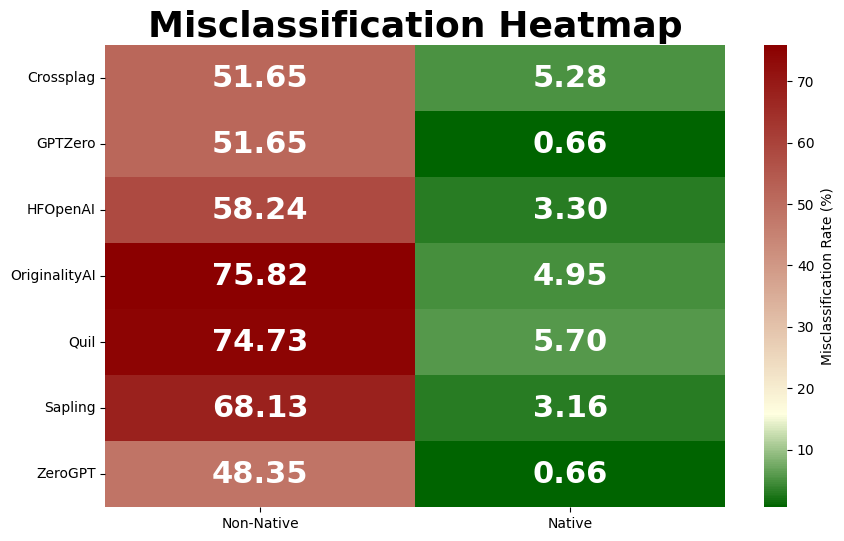
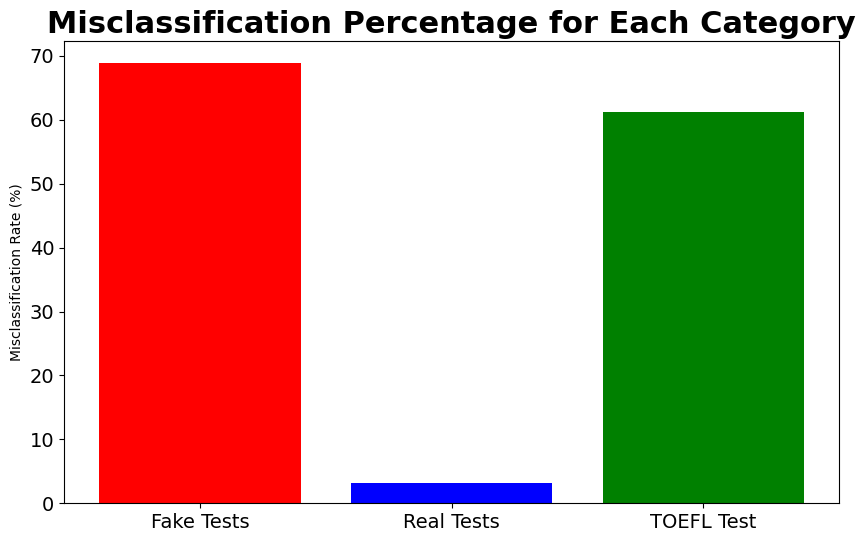

Describe your visualizations and findings. Be clear which chart(s) you are referring to and relate your findings to the hypothesis/task.
Use no more than 150 words and indicate the word count of your description below.

**Description:** The "Misclassification Heatmap" visualizes how often AI detectors incorrectly classify text written by native and non-native English speakers. Darker red signifies higher misclassification rates, while darker green indicates lower rates. Non-native speakers' texts are misclassified much more frequently, ranging from 48% to 76% across all detectors, with OriginalityAI and Quil exceeding 74%. In contrast, misclassification rates for native speakers are consistently much lower, generally below 6%, with some as low as 0.66%. This demonstrates a clear bias, revealing that AI detectors are significantly more likely to misclassify texts from non-native English speakers.


The bar chart shows misclassification rates across categories. "Fake Tests" had the highest error rate, about 69%. "Real Tests" had the lowest, around 3%. The "TOEFL Test" category showed a high misclassification rate near 62%. This indicates AI detectors struggle with "Fake Tests" and "TOEFL Tests" more than authentic human writing.

**Word count**: 143

### B.2

Restate your hypothesis/task below.

**Hypthesis/Task B.2:** Compute the different AI models' performances in fooling the various detectors and what effect the inclusion of prompts while generating the texts has on the performance. The features "kind", "pred_AI", "detector", "model" and "prompt" will be used for this.

Place your visualizations below (max. 2). Make sure that everyting displays correctly in the GitHub file preview.

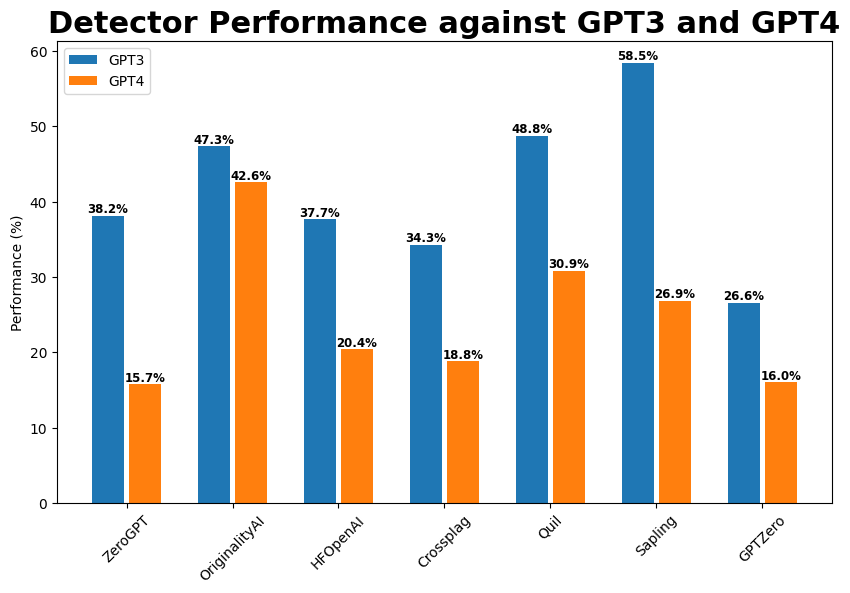
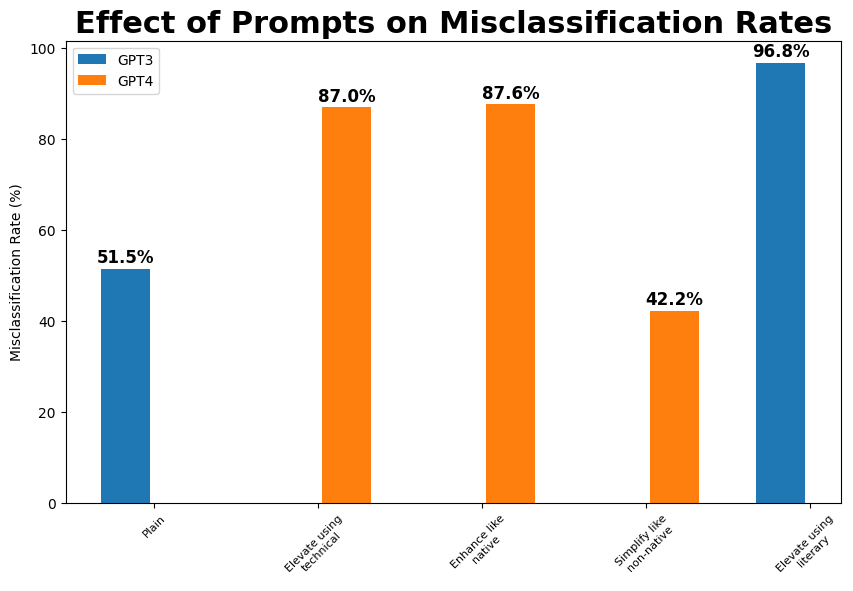

Describe your visualizations and findings. Be clear which chart(s) you are referring to and relate your findings to the hypothesis/task. Use no more than 150 words and indicate the word count of your description below.

**Description:** The first bar chart compares AI detector performance against GPT3 and GPT4 texts. Detectors consistently perform worse against GPT4. GPT3 detection varies between 30-60%, while GPT4 detection is lower, ranging from 15-43%. GPTZero has the poorest overall performance, especially with GPT4 text (16%). Sapling and Quil show large performance drops from GPT3 to GPT4. Detectors are generally less successful classifying GPT4-generated texts, suggesting these are better at deceiving AI detectors.


The second chart shows how prompts affect AI detector misclassification rates for GPT3 and GPT4 text. "Elevate using technical" and "Enhance like native" prompts led to high misclassification rates for GPT4 (87%). "Elevate using literary" caused a very high misclassification rate for GPT3 (96.8%) which is obviously worse than giving it no prompt at all. "Simplify like non-native" resulted in the lowest misclassification for GPT4 (42%). Prompt engineering significantly influences text detection difficulty.


**Word count**: 143

---

## Results &ndash; Black-Hat Visualization

Place your black hat visualization below. Make sure that everything displays correctly in the GitHub file preview.

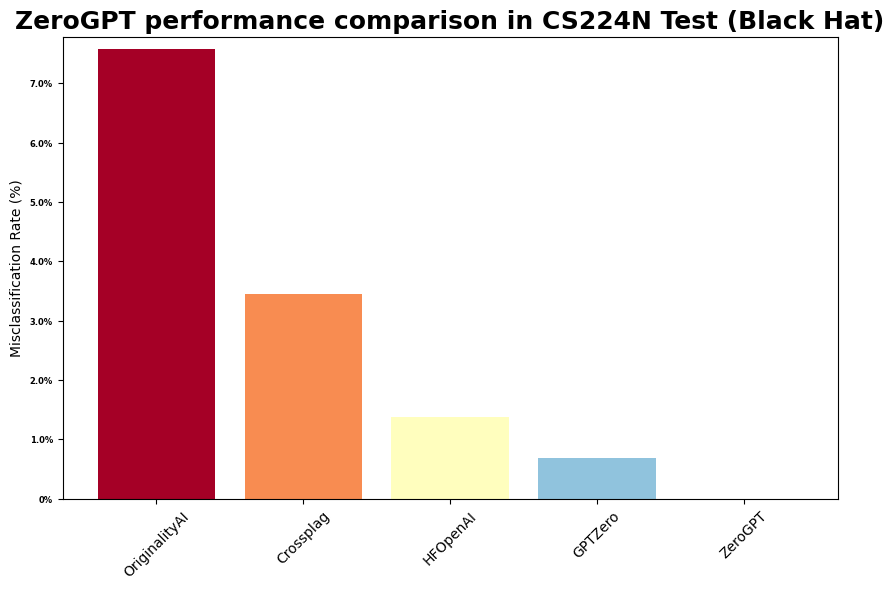

Describe your black-hat visualization. What was your motivation? How did you achieve the desired effect? Use no more than 150 and indicate the word count of your description below.

**Description:** Black-hat visualization compares the performance of ZeroGPT against other detectors in a CS224N test. The graph exaggerates ZeroGPT's effectiveness by selectively focusing on misclassification rates, displaying it as the most accurate detector. To achieve this, the Y-axis starts at 0% but extends disproportionately to amplify small differences, making other detectors seem far less effective. Additionally, the graph uses saturated, alarming colors for higher misclassification rates (e.g., red for OriginalityAI) to imply poor performance, while muted colors represent lower rates, drawing attention away from ZeroGPT's results. Also, we can see the percentages are deceiving (2.0% looks like 20%).

The motivation behind this visualization is to demonstrate how selective scaling, cherry-picked comparisons, and manipulative color schemes can mislead the audience into perceiving ZeroGPT as superior, even when the actual differences might be minor or contextually insignificant. This highlights the potential for visualizations to distort perceptions when used unethically.

**Word count:** 146